In [1]:
import random
import matplotlib.pyplot as plt
from src.preprocessing_2 import *
from src.utils import *
import matplotlib.pyplot as plt
from pathlib import Path
from src.vessel_segmentation import *
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
# Group all paths by serie and pick one randomly to test
paths = get_all_image_paths()
series = group_paths_by_serie(paths)
print(f"Total series found: {len(series)}")

random_serie_key = random.choice(list(series.keys()))
random_serie_paths = series[random_serie_key]

# get 5 subjects
random_series_keys = random.sample(list(series.keys()), k=min(5, len(series)))

print(f"Selected serie : {random_serie_key}")
print(f"Frames in serie: {len(random_serie_paths)}")

Total images found: 8325
Total series found: 214
Selected serie : 085/2
Frames in serie: 41


## Approach 1 — Histogram Matching
For each serie, match all frames' histograms to the **middle frame** — the point in the acquisition where injected contrast is typically at its peak.

In [3]:
# Run histogram matching on the selected serie
results, ref_path = histogram_match_serie(random_serie_paths)
print(f"Reference frame: {ref_path}")

Reference frame: C:\Users\jcgon\PycharmProjects\IPA_ML_StenosisDetection_Project\organized_dataset\085\2\14_085_2_0050.png


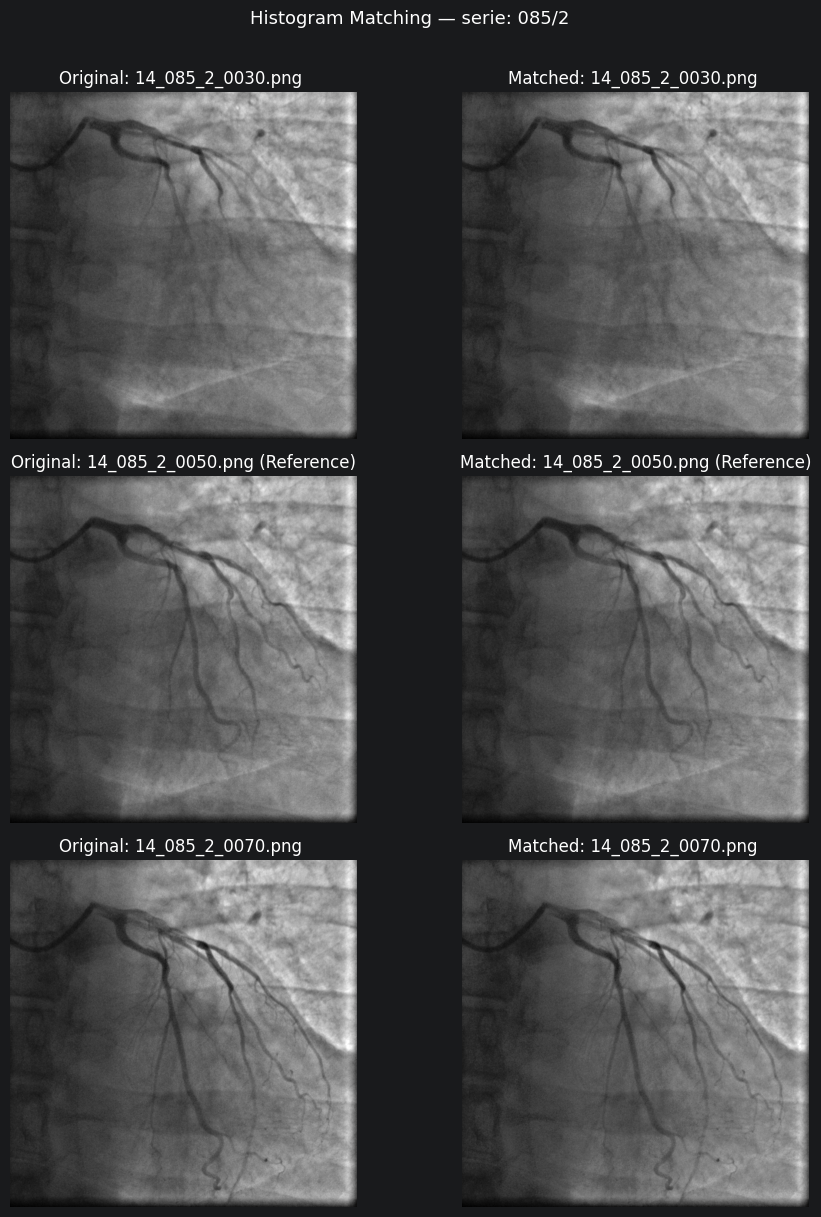

In [4]:
# ── Visual check: show original vs matched for a few frames ──
# Pick the first, middle (reference), and last frame to compare
indices_to_show = sorted({0, len(results) // 2, len(results) - 1})
n = len(indices_to_show)
fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
if n == 1:
    axes = [axes]

for row, idx in enumerate(indices_to_show):
    r = results[idx]

    # Cleanly extract the filename using Path for cross-platform compatibility
    fname = Path(r['path']).name

    # Determine the label based on whether it's the reference frame
    label = "(Reference)" if r['is_ref'] else ""

    # Plot Original Image
    axes[row][0].imshow(r['original'], cmap='gray')
    axes[row][0].set_title(f"Original: {fname} {label}")
    axes[row][0].axis('off')

    # Plot Matched Image
    axes[row][1].imshow(r['matched'], cmap='gray')
    axes[row][1].set_title(f"Matched: {fname} {label}")
    axes[row][1].axis('off')

# Final layout adjustments
plt.suptitle(f"Histogram Matching — serie: {random_serie_key}", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

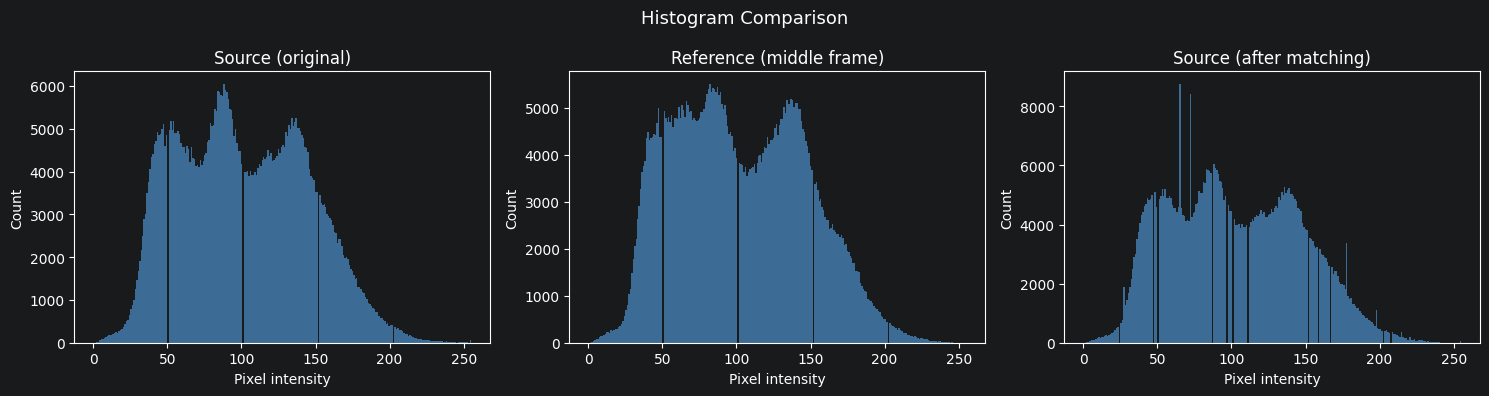

In [5]:
# ── Histogram curves: before vs after for one non-reference frame ──

# Pick the first non-reference frame and the reference frame from the results list
sample = next(r for r in results if not r['is_ref'])
ref    = next(r for r in results if r['is_ref'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Data to plot
images = [sample['original'], ref['original'], sample['matched']]
titles = ['Source (original)', 'Reference (middle frame)', 'Source (after matching)']

for ax, img, title in zip(axes, images, titles):
    # .ravel() flattens the 2D image into a 1D array for the histogram
    ax.hist(img.ravel(), bins=256, range=(0, 255), color='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Pixel intensity')
    ax.set_ylabel('Count')

plt.suptitle('Histogram Comparison', fontsize=13)
plt.tight_layout()
plt.show()

##  Approach 2 — CLAHE
Apply CLAHE to each frame in the serie, using different clip limits to see the effect on contrast enhancement. The clip limit controls how much the histogram is allowed to be amplified, which can help prevent over-enhancement of noise in homogeneous areas.

In [6]:
len(random_serie_paths)

41

In [ ]:
for serie_key in random_series_keys:
    browse_clahe_interactive(
        series[serie_key],
        title=f"{serie_key} | {len(series[serie_key])} frames"
    )

interactive(children=(IntSlider(value=19, description='Frame', max=37), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=28, description='Frame', max=55), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=60, description='Frame', max=120), FloatSlider(value=2.0, description='C…

interactive(children=(IntSlider(value=33, description='Frame', max=65), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=40, description='Frame', max=80), FloatSlider(value=2.0, description='Cl…

In [8]:
clahe_results = {}

for serie_key in random_series_keys:
    paths = series[serie_key]
    clahe_frames = []

    for path in paths:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  ⚠ Could not load: {path}")
            continue

        clahe_frames.append(apply_clahe(img, clip_limit=2.30))

    clahe_results[serie_key] = clahe_frames
    print(f"Serie {serie_key}: {len(clahe_frames)}/{len(paths)} frames processed")

Serie 023/4: 38/38 frames processed
Serie 053/4: 56/56 frames processed
Serie 026/2: 121/121 frames processed
Serie 048/5: 66/66 frames processed
Serie 048/2: 81/81 frames processed


In [ ]:
for serie_key in random_series_keys:
    print(f"\nSerie: {serie_key}")
    browse_nlmeans_interactive(clahe_results[serie_key], title=str(serie_key))


Serie: 023/4


interactive(children=(IntSlider(value=19, description='Frame', max=37), IntSlider(value=10, description='h (st…


Serie: 053/4


interactive(children=(IntSlider(value=28, description='Frame', max=55), IntSlider(value=10, description='h (st…


Serie: 026/2


interactive(children=(IntSlider(value=60, description='Frame', max=120), IntSlider(value=10, description='h (s…


Serie: 048/5


interactive(children=(IntSlider(value=33, description='Frame', max=65), IntSlider(value=10, description='h (st…


Serie: 048/2


interactive(children=(IntSlider(value=40, description='Frame', max=80), IntSlider(value=10, description='h (st…

In [ ]:
for serie_key in random_series_keys:
    print(f"\nSerie: {serie_key}")
    browse_bilateral_interactive(clahe_results[serie_key], title=str(serie_key))


Serie: 023/4


interactive(children=(IntSlider(value=19, description='Frame', max=37), IntSlider(value=9, description='d (dia…


Serie: 053/4


interactive(children=(IntSlider(value=28, description='Frame', max=55), IntSlider(value=9, description='d (dia…


Serie: 026/2


interactive(children=(IntSlider(value=60, description='Frame', max=120), IntSlider(value=9, description='d (di…


Serie: 048/5


interactive(children=(IntSlider(value=33, description='Frame', max=65), IntSlider(value=9, description='d (dia…


Serie: 048/2


interactive(children=(IntSlider(value=40, description='Frame', max=80), IntSlider(value=9, description='d (dia…

In [11]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
#
# # IMPORTANT
# cv2.setNumThreads(1)
#
#
# def process_single_image(args):
#     path, serie_key, output_root, clip_limit, h, template_window, search_window = args
#
#     try:
#         path = Path(path)
#
#         clahe_root = Path(output_root) / "clahe"
#         nlmeans_root = Path(output_root) / "nlmeans"
#
#         img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
#
#         if img is None:
#             return f" Could not load: {path}"
#
#         # CLAHE
#         clahe_img = apply_clahe(img, clip_limit=clip_limit)
#
#         clahe_out = clahe_root / serie_key / path.name
#         clahe_out.parent.mkdir(parents=True, exist_ok=True)
#
#         cv2.imwrite(str(clahe_out), clahe_img)
#
#         # NLMeans
#         nlmeans_img = apply_nlmeans(
#             clahe_img,
#             h=h,
#             template_window=template_window,
#             search_window=search_window
#         )
#
#         nlmeans_out = nlmeans_root / serie_key / path.name
#         nlmeans_out.parent.mkdir(parents=True, exist_ok=True)
#
#         cv2.imwrite(str(nlmeans_out), nlmeans_img)
#
#         return f"✓ {path.name}"
#
#     except Exception as e:
#         return f"✗ {path} -> {e}"
#
#
# def save_preprocessed_parallel(
#     series,
#     output_root=r"C:\Users\jcgon\PycharmProjects\IPA_ML_StenosisDetection_Project\preprocessing",
#     clip_limit=2.30,
#     h=12,
#     template_window=7,
#     search_window=21,
#     max_workers=None
# ):
#
#     if max_workers is None:
#         # safer default
#         max_workers = min(8, os.cpu_count())
#
#     tasks = []
#
#     for serie_key, paths in series.items():
#         for path in paths:
#             tasks.append((
#                 path,
#                 serie_key,
#                 output_root,
#                 clip_limit,
#                 h,
#                 template_window,
#                 search_window
#             ))
#
#     total = len(tasks)
#
#     print(f"Processing {total} images with {max_workers} workers")
#
#     with ThreadPoolExecutor(max_workers=max_workers) as executor:
#
#         futures = [executor.submit(process_single_image, t) for t in tasks]
#
#         for i, future in enumerate(as_completed(futures), 1):
#             print(f"[{i}/{total}] {future.result()}")
#
#     print(f"\nDone — {total} images saved")
#
#
# # RUN
# save_preprocessed_parallel(series)

In [ ]:
for serie_key in random_series_keys:
    browse_background_sub_interactive(
        series[serie_key],
        title=f"{serie_key} | {len(series[serie_key])} frames"
    )

Caching frames for: 023/4 | 38 frames
Done. 38 frames loaded.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=37), FloatSlider(va…

Caching frames for: 053/4 | 56 frames
Done. 56 frames loaded.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=55), FloatSlider(va…

Caching frames for: 026/2 | 121 frames
Done. 121 frames loaded.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=120), FloatSlider(v…

Caching frames for: 048/5 | 66 frames
Done. 66 frames loaded.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=65), FloatSlider(va…

Caching frames for: 048/2 | 81 frames
Done. 81 frames loaded.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Frame', max=80), FloatSlider(va…

In [13]:
bg_results = {}

for serie_key in random_series_keys:
    paths = series[serie_key]
    bg_frames = []

    for path in paths:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  ⚠ Could not load: {path}")
            continue
        bg_frames.append(apply_background_subtraction(img, sigma=20))

    bg_results[serie_key] = bg_frames
    print(f"Serie {serie_key}: {len(bg_frames)}/{len(paths)} frames processed")

Serie 023/4: 38/38 frames processed
Serie 053/4: 56/56 frames processed
Serie 026/2: 121/121 frames processed
Serie 048/5: 66/66 frames processed
Serie 048/2: 81/81 frames processed


In [ ]:
for serie_key in random_series_keys:
    browse_clahe_interactive(
        bg_results[serie_key],
        title=f"{serie_key} | {len(bg_results[serie_key])} frames"
    )

interactive(children=(IntSlider(value=19, description='Frame', max=37), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=28, description='Frame', max=55), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=60, description='Frame', max=120), FloatSlider(value=2.0, description='C…

interactive(children=(IntSlider(value=33, description='Frame', max=65), FloatSlider(value=2.0, description='Cl…

interactive(children=(IntSlider(value=40, description='Frame', max=80), FloatSlider(value=2.0, description='Cl…

In [15]:
clahe_results = {}

for serie_key in random_series_keys:
    paths = series[serie_key]
    clahe_frames = []

    for path in paths:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  ⚠ Could not load: {path}")
            continue

        img = apply_background_subtraction(img, sigma=20)  # ← BG sub first
        clahe_frames.append(apply_clahe(img, clip_limit=2.20))

    clahe_results[serie_key] = clahe_frames
    print(f"Serie {serie_key}: {len(clahe_frames)}/{len(paths)} frames processed")

Serie 023/4: 38/38 frames processed
Serie 053/4: 56/56 frames processed
Serie 026/2: 121/121 frames processed
Serie 048/5: 66/66 frames processed
Serie 048/2: 81/81 frames processed


In [ ]:
for serie_key in random_series_keys:
    print(f"\nSerie: {serie_key}")
    browse_nlmeans_interactive(clahe_results[serie_key], title=str(serie_key))


Serie: 023/4


interactive(children=(IntSlider(value=19, description='Frame', max=37), IntSlider(value=10, description='h (st…


Serie: 053/4


interactive(children=(IntSlider(value=28, description='Frame', max=55), IntSlider(value=10, description='h (st…


Serie: 026/2


interactive(children=(IntSlider(value=60, description='Frame', max=120), IntSlider(value=10, description='h (s…


Serie: 048/5


interactive(children=(IntSlider(value=33, description='Frame', max=65), IntSlider(value=10, description='h (st…


Serie: 048/2


interactive(children=(IntSlider(value=40, description='Frame', max=80), IntSlider(value=10, description='h (st…

In [18]:
nlmeans_results = {}

for serie_key in random_series_keys:
    paths = series[serie_key]
    nlmeans_frames = []

    for path in paths:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  ⚠ Could not load: {path}")
            continue

        img = apply_background_subtraction(img, sigma=20)  # ← BG sub first
        clahe_img = apply_clahe(img, clip_limit=2.20)
        nlmeans_frames.append(apply_nlmeans(
            clahe_img,
            h=20,
            template_window=9,
            search_window=23
        ))

    nlmeans_results[serie_key] = nlmeans_frames
    print(f"Serie {serie_key}: {len(nlmeans_frames)}/{len(paths)} frames processed")

Serie 023/4: 38/38 frames processed
Serie 053/4: 56/56 frames processed
Serie 026/2: 121/121 frames processed
Serie 048/5: 66/66 frames processed
Serie 048/2: 81/81 frames processed


In [19]:
browse_frangi_interactive2(nlmeans_results)

Frames already loaded. Use sliders to explore Frangi parameters.


interactive(children=(Dropdown(description='Serie', options=('023/4', '053/4', '026/2', '048/5', '048/2'), val…

In [ ]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
#
# # IMPORTANT
# cv2.setNumThreads(1)
#
#
# def process_single_image(args):
#     path, serie_key, output_root, clip_limit, h, template_window, search_window = args
#
#     try:
#         path = Path(path)
#
#         clahe_root = Path(output_root) / "clahe"
#         nlmeans_root = Path(output_root) / "nlmeans"
#
#         img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
#
#         if img is None:
#             return f" Could not load: {path}"
#
#
#         # BG background normalization
#         bg_img = apply_background_subtraction(img, sigma=20)
#
#         # CLAHE
#         clahe_img = apply_clahe(bg_img, clip_limit=clip_limit)
#
#         clahe_out = clahe_root / serie_key / path.name
#         clahe_out.parent.mkdir(parents=True, exist_ok=True)
#
#         cv2.imwrite(str(clahe_out), clahe_img)
#
#         # NLMeans
#         nlmeans_img = apply_nlmeans(
#             clahe_img,
#             h=h,
#             template_window=template_window,
#             search_window=search_window
#         )
#
#         nlmeans_out = nlmeans_root / serie_key / path.name
#         nlmeans_out.parent.mkdir(parents=True, exist_ok=True)
#
#         cv2.imwrite(str(nlmeans_out), nlmeans_img)
#
#         return f"✓ {path.name}"
#
#     except Exception as e:
#         return f"✗ {path} -> {e}"
#
#
# def save_preprocessed_parallel(
#     series,
#     output_root=r"C:\Users\jcgon\PycharmProjects\IPA_ML_StenosisDetection_Project\preprocessing_with_denoising",
#     clip_limit=2.20,
#     h=20,
#     template_window=9,
#     search_window=23,
#     max_workers=None
# ):
#
#     if max_workers is None:
#         # safer default
#         max_workers = min(8, os.cpu_count())
#
#     tasks = []
#
#     for serie_key, paths in series.items():
#         for path in paths:
#             tasks.append((
#                 path,
#                 serie_key,
#                 output_root,
#                 clip_limit,
#                 h,
#                 template_window,
#                 search_window
#             ))
#
#     total = len(tasks)
#
#     print(f"Processing {total} images with {max_workers} workers")
#
#     with ThreadPoolExecutor(max_workers=max_workers) as executor:
#
#         futures = [executor.submit(process_single_image, t) for t in tasks]
#
#         for i, future in enumerate(as_completed(futures), 1):
#             print(f"[{i}/{total}] {future.result()}")
#
#     print(f"\nDone — {total} images saved")
#
#
# # RUN
# save_preprocessed_parallel(series)

In [ ]:
# modification